# Capitolo 4: sintesi quantitativa e correlazioni
Questo notebook rappresenta il nucleo analitico e pratico della ricerca. Fino a questo punto, nei Capitoli 2 e 3, ci siamo concentrati su un'osservazione di tipo descrittivo: abbiamo mappato lo scenario delle minacce in Italia e inquadrato il divario macroeconomico che ci separa dall'Europa.
L'obiettivo di questo notebook è passare da una semplice "fotografia" della situazione alla ricerca di vere e proprie relazioni causa-effetto attraverso modelli statistici.

## 4.1 Analisi bivariata: il legame tra struttura vulnerabile e competenze

In questo notebook andiamo a tradurre in codice l'analisi statistica discussa nel primo paragrafo del Capitolo 4. L'obiettivo è rispondere, dati alla mano, a una domanda cruciale: l'elevato livello di esternalizzazione dei servizi IT nelle aziende italiane è una reale scelta strategica aziendale, oppure è la diretta conseguenza della mancanza di competenze interne?

Per capirlo, l'analisi si concentra sulle dinamiche interne al nostro tessuto produttivo. Andremo ad elaborare il dataset ufficiale ISTAT ("Competenze e formazione in ICT"), isolando i principali comparti economici nazionali (classificazione ATECO 2007).

Attraverso un'analisi bivariata e la costruzione di una matrice di correlazione (calcolando il coefficiente di Pearson), andremo a verificare matematicamente se esiste un legame strutturale tra queste quattro variabili chiave:

La percentuale di specialisti ICT assunti internamente.

Gli investimenti in formazione.

Lo Skill Shortage.

La dipendenza dall'Outsourcing IT.

Per gestire le anomalie del file ISTAT ho usato pandas per la lettura, con l'opzione `on_bad_lines='skip'` per saltare le righe malformate, e poi ho convertito il DataFrame in Polars per l'elaborazione successiva. Questo approccio mi ha permesso di superare i problemi di parsing senza perdere dati utili.

In [ ]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

df_pandas = pd.read_csv(
    "../data/raw/Competenze e formazione in ICT (IT1,6_39_DF_DCSP_ICT_14,1.0).csv",
    quotechar="'",
    escapechar="\\",
    on_bad_lines='skip'
)
df = pl.from_pandas(df_pandas)

indicatori_map = {
    'E_ITSP2_PERC': 'Specialisti Interni',
    'E_ITT2_PERC': 'Formazione Dipendenti',
    'E_ITSPVAC2_PERC': 'Skill Shortage',
    'E_IT_EXT_PERC': 'Outsourcing IT'
}

settori_codici = ['55', 'C', 'M', 'F', '47', '0033', '61', '56', 'CA', 'CB', 'CC', 'CD-CG', 'CH', '26', 'CJ-CK', 'CL', 'CM', '0036', 'G', '0049', '53', 'JA_X_58', '58', '61', 'JC', '68']

col_order = ['Specialisti Interni', 'Formazione Dipendenti', 'Skill Shortage', 'Outsourcing IT']

df_filtered = (
    df.filter(
        pl.col('DATA_TYPE').is_in(list(indicatori_map.keys())) &
        pl.col('ECON_ACTIVITY_NACE_2007').is_in(settori_codici)
    )
    .with_columns([
        pl.col('DATA_TYPE').replace(indicatori_map).alias('Indicatore_Breve'),
        pl.col('Osservazione')
            .cast(pl.Utf8)
            .str.replace_all(",", ".")
            .cast(pl.Float64, strict=False)
            .alias('VALUE'),
    ])
    .filter(pl.col('VALUE').is_not_null())
)

df_pivot = df_filtered.pivot(
    index='ECON_ACTIVITY_NACE_2007',
    on='Indicatore_Breve',
    values='VALUE',
    aggregate_function='mean'
)

existing_cols = [c for c in col_order if c in df_pivot.columns]
df_pivot = df_pivot.select(existing_cols).drop_nulls()

cols = existing_cols
corr_matrix = np.zeros((len(cols), len(cols)))
pval_matrix = np.zeros((len(cols), len(cols)))

for i in range(len(cols)):
    for j in range(len(cols)):
        x = df_pivot.get_column(cols[i]).to_numpy()
        y = df_pivot.get_column(cols[j]).to_numpy()

        mask = ~np.isnan(x) & ~np.isnan(y)

        if mask.sum() >= 3:
            r_val, p_val = pearsonr(x[mask], y[mask])
            corr_matrix[i, j] = r_val
            pval_matrix[i, j] = p_val
        else:
            corr_matrix[i, j] = np.nan
            pval_matrix[i, j] = np.nan

df_corr = pd.DataFrame(corr_matrix, index=cols, columns=cols)

def build_annot(corr_mat, pval_mat):
    annot = np.empty(corr_mat.shape, dtype=object)
    for i in range(corr_mat.shape[0]):
        for j in range(corr_mat.shape[1]):
            if np.isnan(corr_mat[i, j]):
                annot[i, j] = ""
            else:
                stars = ""
                if pval_mat[i, j] < 0.001:
                    stars = "***"
                elif pval_mat[i, j] < 0.01:
                    stars = "**"
                elif pval_mat[i, j] < 0.05:
                    stars = "*"
                annot[i, j] = f"{corr_mat[i, j]:.2f}{stars}"
    return annot

annot = build_annot(corr_matrix, pval_matrix)

plt.figure(figsize=(9, 7), facecolor='white')
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'serif'

heatmap = sns.heatmap(
    df_corr,
    annot=annot,
    fmt="",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Coefficiente di Pearson (r)'},
    square=True,
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title(
    "Matrice di correlazione: Competenze vs Vulnerabilità \n(Settori Economici Italiani)",
    fontsize=14, pad=20,
)

heatmap.set_xticklabels(cols, rotation=45, ha='right', fontsize=11)
heatmap.set_yticklabels(cols, rotation=0, fontsize=11)

plt.xlabel('')
plt.ylabel('')
plt.tight_layout()

plt.savefig("../reports/img/figura_4_1_heatmap_pearson.png", dpi=300, bbox_inches='tight')
plt.show()

df_corr.to_csv("tabella_corr_pearson.csv")
pval_df = pd.DataFrame(pval_matrix, index=cols, columns=cols)
pval_df.to_csv("tabella_pvalue_pearson.csv")

print("Legenda: * p<0.05, ** p<0.01, *** p<0.001")
print("=" * 70)

## 4.2 Posizionamento dell’Italia rispetto a gruppi omogenei di Paesi europei

Questa sezione mira a collocare l’Italia nel contesto europeo attraverso una **classificazione descrittiva dei Paesi UE-27**, basata sulla relazione tra:
- **Maturità Digitale** (variabile indipendente, asse X),
- **Vulnerabilità Osservata** (variabile dipendente, asse Y).

L’obiettivo interpretativo è verificare se l’Italia ricade in un’area coerente con l’ipotesi di **vulnerabilità strutturale** emersa nei paragrafi precedenti.

---

### Fonti dati utilizzate (Eurostat, anno 2024)
L’analisi utilizza i seguenti dataset (imprese con almeno 10 addetti):

- `isoc_ske_itspen2` → imprese con specialisti ICT (D1)
- `isoc_ske_ittn2` → imprese che erogano formazione ICT al personale (D2)
- `isoc_cisce_ran2`:
  - `E_SECMOSBU` (backup),
  - `E_SECMDUO` (MFA),
  - `E_SECMVPN` (VPN)
  Questi tre indicatori compongono la dimensione D3 (hardening)
- `isoc_cisce_ic` → imprese che hanno subito incidenti ICT con impatto operativo (VO)

Sono inclusi esclusivamente i **27 Paesi dell’Unione Europea**.

---

### Definizione delle variabili

#### 1) Maturità Digitale (MD)
L’indice composito di maturità digitale è costruito in tre passaggi:

1. **D3 – Hardening operativo**:
\[
D_3 = \frac{\%Backup + \%MFA + \%VPN}{3}
\]

2. **Standardizzazione z-score** delle tre dimensioni:
\[
Z_{D1},\; Z_{D2},\; Z_{D3}
\]

3. **Indice composito**:
\[
MD = \frac{Z_{D1} + Z_{D2} + Z_{D3}}{3}
\]

---

#### 2) Vulnerabilità Osservata (VO)
La vulnerabilità osservata corrisponde alla percentuale di imprese che dichiarano incidenti ICT:
\[
VO = \% \text{ imprese con incidenti ICT}
\]

Per coerenza metodologica con MD:
\[
Z_{VO} = \frac{VO - \mu_{VO}}{\sigma_{VO}}
\]

---

### Metodo di classificazione descrittiva
La classificazione avviene tramite **scatter plot**:
- asse X = `MD`
- asse Y = `Z_VO`

Le soglie dei quadranti sono fissate alla media UE standardizzata:
- linea verticale: \(x = 0\)
- linea orizzontale: \(y = 0\)

Ne derivano quattro gruppi:

1. **Best performers**: alta maturità, bassa vulnerabilità \((MD \ge 0,\; Z_{VO} < 0)\)
2. **Vulnerabili**: bassa maturità, alta vulnerabilità \((MD < 0,\; Z_{VO} \ge 0)\)
3. **Alta maturità, alta vulnerabilità** \((MD \ge 0,\; Z_{VO} \ge 0)\)
4. **Bassa maturità, bassa vulnerabilità** \((MD < 0,\; Z_{VO} < 0)\)

---

### Criteri interpretativi
- Un valore **MD > 0** indica un livello di maturità superiore alla media UE.
- Un valore **Z_VO > 0** indica una vulnerabilità osservata superiore alla media UE.
- Il quadrante di appartenenza dell’Italia consente una lettura sintetica del suo profilo comparato.

---

[INFO] Paesi UE-27 con dati completi: 27/27
[OK] Dataset finale: cap4_2_dataset_finale_ue27.csv
[OK] Classificazione quadranti: cap4_2_classificazione_quadranti_ue27.csv
[OK] Ranking MD: cap4_2_ranking_md_ue27.csv
[OK] Focus Italia: cap4_2_focus_italia.csv
[OK] Figura salvata: figura_4_2_scatter_md_vs_vulnerabilita_ue27.png

================ RECAP ================

Distribuzione paesi per gruppo:
Gruppo_descrittivo
Laggers (Bassa maturità, Bassa vulnerabilità)           8
Over-Targeted (Alta maturità, Alta vulnerabilità)       8
Best performers (Alta maturità, Bassa vulnerabilità)    7
Vulnerabili (Bassa maturità, Alta vulnerabilità)        4
Name: count, dtype: int64

Posizionamento Italia:
  MD   = -0.786
  Z_VO = -0.542
  VO   = 15.78%
  Gruppo = Laggers (Bassa maturità, Bassa vulnerabilità)




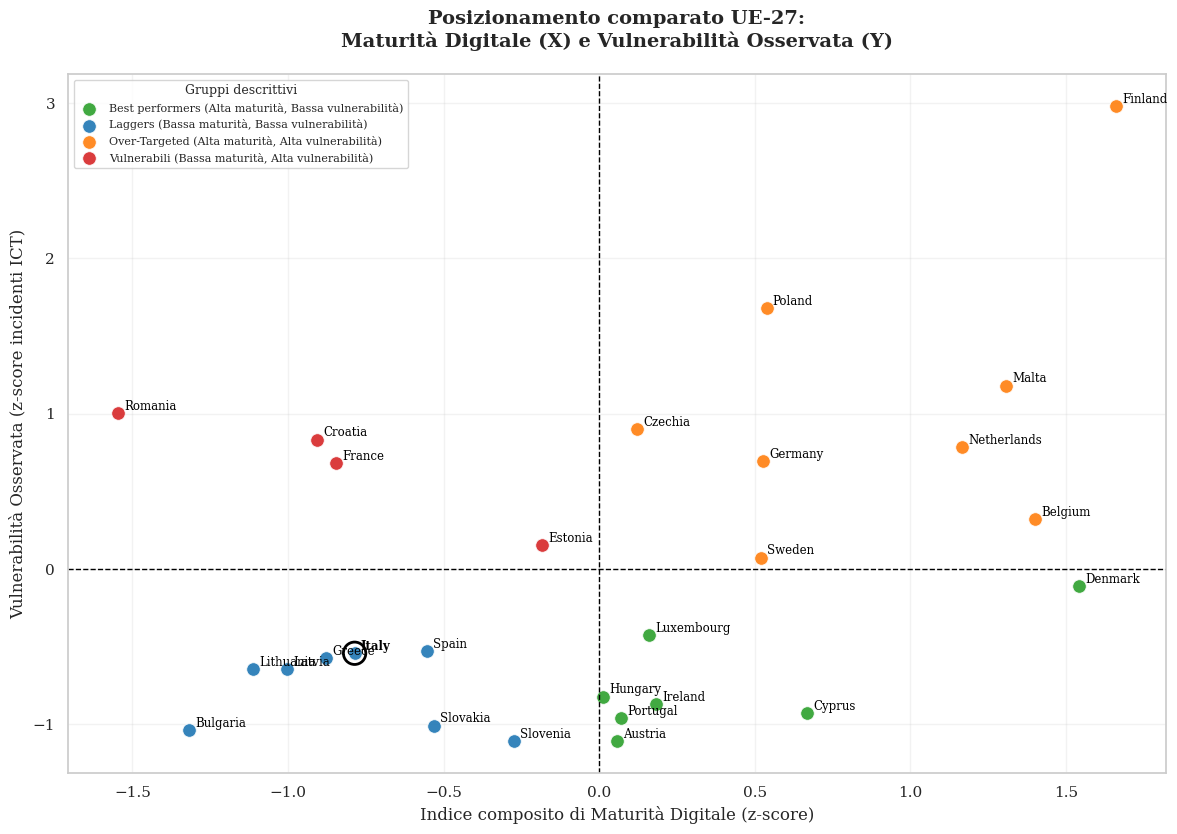

In [4]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List

@dataclass(frozen=True)
class Config:
    f_vo: str = "../data/raw/isoc_cisce_ic_page_linear.csv"                         # Vulnerabilità osservata
    f_d1: str = "../data/raw/isoc_ske_itspen2_page_linear.csv"                      # Specialisti ICT
    f_d2: str = "../data/raw/isoc_ske_ittn2_page_linear.csv"                        # Training ICT
    f_mfa: str = "../data/raw/isoc_cisce_ran2_page_linear_E_SECMDUO.csv"            # MFA
    f_backup: str = "../data/raw/isoc_cisce_ran2_page_linear_E_SECMOSBU_backup.csv" # Backup
    f_vpn: str = "../data/raw/isoc_cisce_ran2_page_linear_E_SECMVPN.csv"            # VPN

    out_dataset: str = "cap4_2_dataset_finale_ue27.csv"
    out_quadranti: str = "cap4_2_classificazione_quadranti_ue27.csv"
    out_ranking_md: str = "cap4_2_ranking_md_ue27.csv"
    out_italia: str = "cap4_2_focus_italia.csv"
    out_fig: str = "figura_4_2_scatter_md_vs_vulnerabilita_ue27.png"

    year: int = 2024
    size_emp: str = "10 persons employed or more"

    fig_w: float = 12.0
    fig_h: float = 8.5
    dpi: int = 300

CFG = Config()

UE27: List[str] = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark",
    "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Ireland",
    "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta", "Netherlands",
    "Poland", "Portugal", "Romania", "Slovakia", "Slovenia", "Spain", "Sweden"
]

def load_indicator(path: str, value_name: str, cfg: Config) -> pl.DataFrame:
    df = pl.read_csv(path)

    df = df.with_columns([
        pl.col("TIME_PERIOD").cast(pl.Int64, strict=False),
        pl.col("OBS_VALUE").cast(pl.Float64, strict=False),
        pl.col("size_emp").cast(pl.Utf8),
        pl.col("geo").cast(pl.Utf8),
    ])

    df = df.filter(
        (pl.col("TIME_PERIOD") == cfg.year) &
        (pl.col("size_emp") == cfg.size_emp) &
        (pl.col("geo").is_in(UE27)) &
        (pl.col("OBS_VALUE").is_not_null())
    )

    df = df.group_by("geo").agg(
        pl.col("OBS_VALUE").mean().alias(value_name)
    )

    return df


def add_zscore(df: pl.DataFrame, col: str, new_col: str) -> pl.DataFrame:
    return df.with_columns(
        ((pl.col(col) - pl.col(col).mean()) / pl.col(col).std(ddof=0)).alias(new_col)
    )


def classify_quadrant(md: float, z_vo: float) -> str:
    if md >= 0 and z_vo < 0:
        return "Best performers (Alta maturità, Bassa vulnerabilità)"
    if md < 0 and z_vo >= 0:
        return "Vulnerabili (Bassa maturità, Alta vulnerabilità)"
    if md >= 0 and z_vo >= 0:
        return "Over-Targeted (Alta maturità, Alta vulnerabilità)"
    return "Laggers (Bassa maturità, Bassa vulnerabilità)"


def style_plot():
    sns.set_theme(style="whitegrid")
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["axes.titleweight"] = "bold"

def main(cfg: Config):
    vo = load_indicator(cfg.f_vo, "VO", cfg)
    d1 = load_indicator(cfg.f_d1, "D1_specialisti", cfg)
    d2 = load_indicator(cfg.f_d2, "D2_formazione", cfg)
    mfa = load_indicator(cfg.f_mfa, "MFA", cfg)
    bkp = load_indicator(cfg.f_backup, "BACKUP", cfg)
    vpn = load_indicator(cfg.f_vpn, "VPN", cfg)

    df = (
        vo.join(d1, on="geo", how="inner")
          .join(d2, on="geo", how="inner")
          .join(mfa, on="geo", how="inner")
          .join(bkp, on="geo", how="inner")
          .join(vpn, on="geo", how="inner")
    )

    n_countries = df.height
    print(f"[INFO] Paesi UE-27 con dati completi: {n_countries}/27")
    if n_countries < 27:
        missing = sorted(set(UE27) - set(df["geo"].to_list()))
        print(f"[WARN] Paesi esclusi per dati incompleti: {missing}")

    df = df.with_columns(
        ((pl.col("BACKUP") + pl.col("MFA") + pl.col("VPN")) / 3).alias("D3_hardening")
    )

    df = add_zscore(df, "D1_specialisti", "Z_D1")
    df = add_zscore(df, "D2_formazione", "Z_D2")
    df = add_zscore(df, "D3_hardening", "Z_D3")
    df = add_zscore(df, "VO", "Z_VO")

    df = df.with_columns(
        ((pl.col("Z_D1") + pl.col("Z_D2") + pl.col("Z_D3")) / 3).alias("MD")
    )

    pdf = df.to_pandas()
    pdf["Gruppo_descrittivo"] = pdf.apply(
        lambda r: classify_quadrant(r["MD"], r["Z_VO"]), axis=1
    )

    pdf_rank_md = pdf.sort_values("MD", ascending=False).copy()
    pdf_quadranti = pdf.sort_values(["Gruppo_descrittivo", "MD"], ascending=[True, False]).copy()
    pdf_italia = pdf[pdf["geo"] == "Italy"].copy()

    pdf.to_csv(cfg.out_dataset, index=False)
    pdf_quadranti.to_csv(cfg.out_quadranti, index=False)
    pdf_rank_md[["geo", "MD", "Z_VO", "VO", "Gruppo_descrittivo"]].to_csv(cfg.out_ranking_md, index=False)
    pdf_italia.to_csv(cfg.out_italia, index=False)

    print(f"[OK] Dataset finale: {cfg.out_dataset}")
    print(f"[OK] Classificazione quadranti: {cfg.out_quadranti}")
    print(f"[OK] Ranking MD: {cfg.out_ranking_md}")
    print(f"[OK] Focus Italia: {cfg.out_italia}")

    style_plot()

    palette = {
        "Best performers (Alta maturità, Bassa vulnerabilità)": "#2ca02c",
        "Vulnerabili (Bassa maturità, Alta vulnerabilità)": "#d62728",
        "Over-Targeted (Alta maturità, Alta vulnerabilità)": "#ff7f0e",
        "Laggers (Bassa maturità, Bassa vulnerabilità)": "#1f77b4",
    }

    fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h), facecolor="white")

    for grp, g in pdf.groupby("Gruppo_descrittivo"):
        ax.scatter(
            g["MD"], g["Z_VO"],
            s=95, alpha=0.9, color=palette.get(grp, "gray"),
            edgecolors="white", linewidths=0.6, label=grp
        )

    for _, row in pdf.iterrows():
        is_it = row["geo"] == "Italy"
        ax.text(
            row["MD"] + 0.02, row["Z_VO"] + 0.02, row["geo"],
            fontsize=8.5, weight="bold" if is_it else "normal", color="black"
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    it = pdf[pdf["geo"] == "Italy"]
    if not it.empty:
        ax.scatter(
            it["MD"], it["Z_VO"],
            s=260, facecolors="none", edgecolors="black", linewidths=2.0, zorder=5
        )

    ax.set_title(
        "Posizionamento comparato UE-27:\n"
        "Maturità Digitale (X) e Vulnerabilità Osservata (Y)", fontsize=14, pad=20
    )
    ax.set_xlabel("Indice composito di Maturità Digitale (z-score)")
    ax.set_ylabel("Vulnerabilità Osservata (z-score incidenti ICT)")
    ax.legend(title="Gruppi descrittivi", fontsize=8, title_fontsize=9, loc="best", frameon=True)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(cfg.out_fig, dpi=cfg.dpi, bbox_inches="tight")
    print(f"[OK] Figura salvata: {cfg.out_fig}")

    print("\n================ RECAP ================\n")
    print("Distribuzione paesi per gruppo:")
    print(pdf["Gruppo_descrittivo"].value_counts())

    if not pdf_italia.empty:
        it_row = pdf_italia.iloc[0]
        print("\nPosizionamento Italia:")
        print(f"  MD   = {it_row['MD']:.3f}")
        print(f"  Z_VO = {it_row['Z_VO']:.3f}")
        print(f"  VO   = {it_row['VO']:.2f}%")
        print(f"  Gruppo = {it_row['Gruppo_descrittivo']}")
    print("\n=====================================================\n")

main(CFG)